# Skiver's performance using single reference

In [31]:
report_full = "../../output/zymo/skiver/ERR3152366_ref.summary_error_rate.csv"
report_isolates = "../../output/additional_information/skiver_zymo_individual/"

isolate_names = ["$\it{Listeria}$ $\it{monocytogenes}$", 
                 "$\it{Pseudomonas}$ $\it{aeruginosa}$",
                 "$\it{Bacillus}$ $\it{subtilis}$",
                 "$\it{Saccharomyces}$ $\it{cerevisiae}$",
                 "$\it{Escherichia}$ $\it{coli}$",
                 "$\it{Salmonella}$ $\it{enterica}$",
                 "$\it{Lactobacillus}$ $\it{fermentum}$",
                 "$\it{Enterococcus}$ $\it{faecalis}$",
                 "$\it{Cryptococcus}$ $\it{neoformans}$",
                 "$\it{Staphylococcus}$ $\it{aureus}$"]

isolate_genome_names = ["Listeria_monocytogenes_complete_genome", 
                 "Pseudomonas_aeruginosa_complete_genome",
                 "Bacillus_subtilis_complete_genome",
                 "Saccharomyces_cerevisiae_draft_genome",
                 "Escherichia_coli_complete_genome",
                 "Salmonella_enterica_complete_genome",
                 "Lactobacillus_fermentum_complete_genome",
                 "Enterococcus_faecalis_complete_genome",
                 "Cryptococcus_neoformans_draft_genome",
                 "Staphylococcus_aureus_complete_genome"]


theoretical_abundance = [0.891, 0.089, 0.0089, 0.0089, 0.00089, 0.00089, 0.000089, 0.0000089, 0.0000089, 0.00000089]

<>:4: SyntaxWarning: invalid escape sequence '\i'
<>:5: SyntaxWarning: invalid escape sequence '\i'
<>:6: SyntaxWarning: invalid escape sequence '\i'
<>:7: SyntaxWarning: invalid escape sequence '\i'
<>:8: SyntaxWarning: invalid escape sequence '\i'
<>:9: SyntaxWarning: invalid escape sequence '\i'
<>:10: SyntaxWarning: invalid escape sequence '\i'
<>:11: SyntaxWarning: invalid escape sequence '\i'
<>:12: SyntaxWarning: invalid escape sequence '\i'
<>:13: SyntaxWarning: invalid escape sequence '\i'
<>:4: SyntaxWarning: invalid escape sequence '\i'
<>:5: SyntaxWarning: invalid escape sequence '\i'
<>:6: SyntaxWarning: invalid escape sequence '\i'
<>:7: SyntaxWarning: invalid escape sequence '\i'
<>:8: SyntaxWarning: invalid escape sequence '\i'
<>:9: SyntaxWarning: invalid escape sequence '\i'
<>:10: SyntaxWarning: invalid escape sequence '\i'
<>:11: SyntaxWarning: invalid escape sequence '\i'
<>:12: SyntaxWarning: invalid escape sequence '\i'
<>:13: SyntaxWarning: invalid escape sequen

In [32]:
import pandas as pd

# Read the full report
full_report_df = pd.read_csv(report_full)
error_full = full_report_df["per_base_error_rate"].item()

In [33]:
error_rate_list = []


for i in range(len(isolate_names)):
    isolate_report_path = report_isolates + isolate_genome_names[i] + ".summary_error_rate.csv"
    isolate_report_df = pd.read_csv(isolate_report_path)
    identity_isolate = isolate_report_df["per_base_error_rate"].item()

    error_rate_list.append(identity_isolate)
    

In [34]:
error_rate_list

[0.074522,
 0.077216,
 0.047821,
 0.1014,
 0.107805,
 0.151791,
 0.127228,
 0.090868,
 0.526527,
 4e-06]

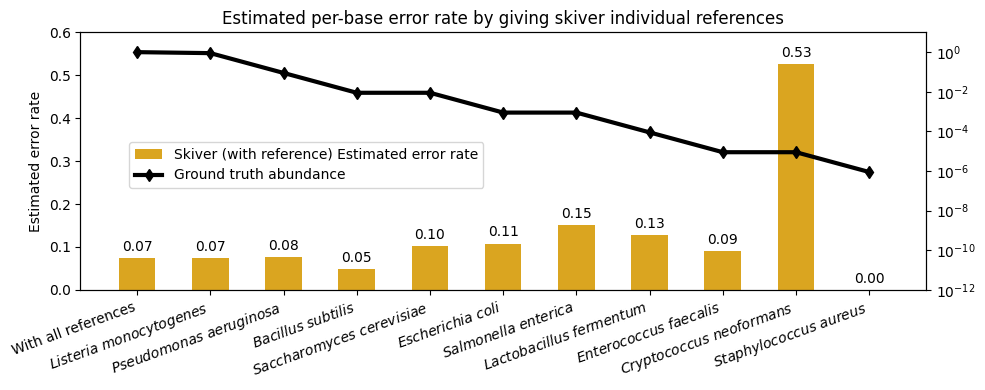

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# Plot the results: Bar plot of the identity for the full & each isolate, along with two line plots for the number of alignments (normalized by the total number of alignments) and theoretical abundance in log scale.
plt.rcParams['font.family'] = 'sans serif'
x = np.arange(len(isolate_names) + 1)  # the label locations
width = 0.5  # the width of the bars
fig, ax1 = plt.subplots(figsize=(10, 4))
bars = ax1.bar(x, [error_full] + error_rate_list, width, color='goldenrod', label='Skiver (with reference) Estimated error rate')
ax1.set_ylabel('Estimated error rate')
ax1.set_xticks(x)
ax1.set_xticklabels(['With all references'] + isolate_names, rotation=20, ha='right')
ax1.tick_params(axis='y')
ax1.set_ylim(0, 0.6)
ax1.bar_label(bars, fmt='%.2f', padding=3)
ax1.set_title('Estimated per-base error rate by giving skiver individual references')
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

line2, = ax2.plot(x, [1.0] + theoretical_abundance, color='black', marker='d', linewidth=3, label='Ground truth abundance')
#line1, = ax2.plot(x, [1.0] + num_alignments_normalized, color='slategray', marker='o', linestyle='--', linewidth=3, label='% Reads mapped by Minimap2')
#ax2.set_ylabel('% Reads mapped / Theoretical Abundance')
ax2.set_yscale('log')
ax2.tick_params(axis='y')
ax2.set_ylim(1e-12, 10)
fig.legend(bbox_to_anchor=(0.5, 0.65))
fig.tight_layout()  # otherwise the right y-label is slightly clipped

plt.savefig("../../figures/skiver_zymo_vs_isolates_error_rate_ref.pdf")